# Birnbaum-Saunders (Fatigue Life) Distribution

The **Birnbaum-Saunders distribution** was derived from a model of crack growth in materials under cyclic stress. It is used in **fatigue life analysis** — modeling the number of cycles to failure when cracks accumulate from repeated loading.

| Property | Value |
|---|---|
| **Parameters** | γ (shape), β (scale), μ (location) |
| **Support** | (μ, +∞) |
| **Mean** | μ + β(1 + γ²/2) |
| **Std Dev** | β · γ · √(1 + 5γ²/4) |
| **Skewness** | Right-skewed (increases with γ) |
| **Relationship** | Related to Inverse Gaussian and Lognormal |
| **Use cases** | Fatigue life, crack propagation, material strength, reliability |
| **Estimation** | MLE (no closed form — numerical optimisation) |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

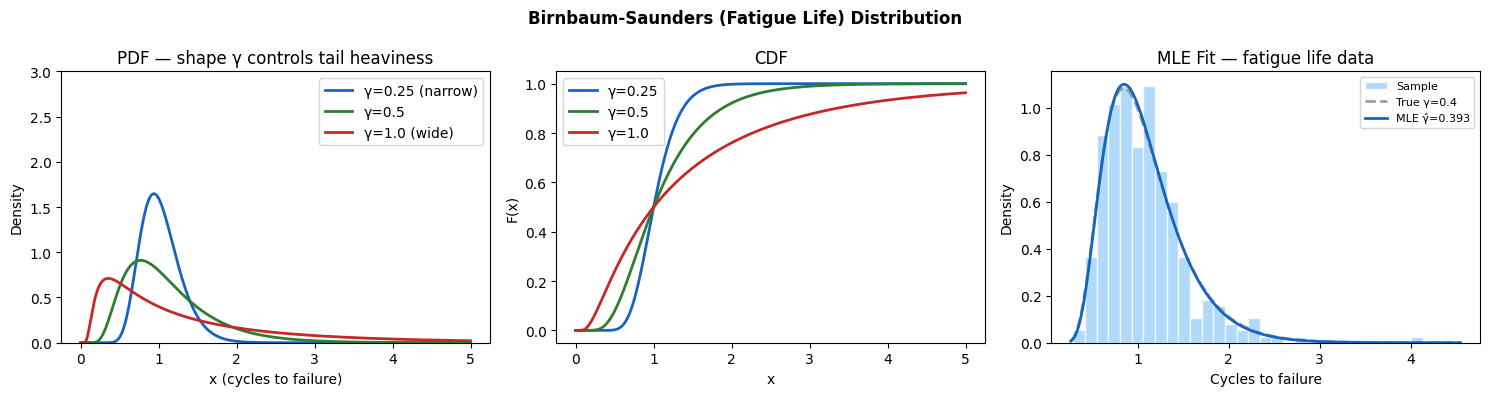

True: γ=0.4, β=1.0
MLE:  γ̂=0.393, β̂=0.999


In [2]:
# scipy implements Birnbaum-Saunders as 'fatiguelife'
x = np.linspace(0.001, 5, 400)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Birnbaum-Saunders (Fatigue Life) Distribution', fontsize=12, fontweight='bold')

# PDF for varying shape γ (scipy: c=gamma)
for gamma, color, label in [(0.25, '#1565C0', 'γ=0.25 (narrow)'),
                              (0.5,  '#2E7D32', 'γ=0.5'),
                              (1.0,  '#C62828', 'γ=1.0 (wide)')]:
    axes[0].plot(x, stats.fatiguelife(c=gamma).pdf(x), color=color, linewidth=2, label=label)
axes[0].set_title('PDF — shape γ controls tail heaviness')
axes[0].set_xlabel('x (cycles to failure)'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 3.0)
axes[0].legend()

# CDF
for gamma, color, label in [(0.25, '#1565C0', 'γ=0.25'),
                              (0.5,  '#2E7D32', 'γ=0.5'),
                              (1.0,  '#C62828', 'γ=1.0')]:
    axes[1].plot(x, stats.fatiguelife(c=gamma).cdf(x), color=color, linewidth=2, label=label)
axes[1].set_title('CDF')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend()

# Fatigue life simulation
np.random.seed(42)
gamma_true, beta_true = 0.4, 1.0
sample = stats.fatiguelife(c=gamma_true, scale=beta_true).rvs(300)

# Fit
c_fit, loc_fit, scale_fit = stats.fatiguelife.fit(sample, floc=0)

x_fit = np.linspace(sample.min()*0.9, sample.max()*1.1, 300)
axes[2].hist(sample, bins=30, density=True, color='#90CAF9', edgecolor='white',
             alpha=0.7, label='Sample')
axes[2].plot(x_fit, stats.fatiguelife(c=gamma_true, scale=beta_true).pdf(x_fit),
             color='#9E9E9E', linewidth=2, linestyle='--', label=f'True γ={gamma_true}')
axes[2].plot(x_fit, stats.fatiguelife(c=c_fit, loc=loc_fit, scale=scale_fit).pdf(x_fit),
             color='#1565C0', linewidth=2, label=f'MLE γ̂={c_fit:.3f}')
axes[2].set_title('MLE Fit — fatigue life data')
axes[2].set_xlabel('Cycles to failure'); axes[2].set_ylabel('Density')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"True: γ={gamma_true}, β={beta_true}")
print(f"MLE:  γ̂={c_fit:.3f}, β̂={scale_fit:.3f}")

## Key Takeaways

| | |
|---|---|
| **Physical model** | Derived from crack growth: failure when accumulated damage exceeds threshold |
| **Shape γ** | Small γ → symmetric; large γ → heavy right tail |
| **vs Weibull** | Both model failure times; Birnbaum-Saunders has a physical crack-growth justification |
| **vs Lognormal** | Similar shape; both model products of small incremental damage |
| **Scale β** | Median of the distribution (when μ=0) |
| **Use** | Fatigue life of metals, composites; S-N curve (stress vs cycles to failure) modeling |